# Error Analysis

Residuals, worst predictions, segment MAE, long-tail performance, business insights.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

In [2]:
preds = pd.read_csv('../reports/test_predictions.csv', parse_dates=['created_at'])
preds.head()

,created_at,market_id,store_primary_category,delivery_duration,pred_Linear_Regression_baseline,pred_Linear_Regression,pred_Decision_Tree,pred_Random_Forest,pred_XGBoost
0,2015-02-13 04:06:44,4.0,other,2745.0,2883.464902,2695.840757,2670.064662,2494.768751,2433.2903
1,2015-02-13 04:06:56,1.0,thai,1956.0,2832.700622,2678.794472,2741.924370,2498.480731,2303.5910
2,2015-02-13 04:06:56,2.0,indian,2065.0,3178.701081,3286.330293,2913.244980,2964.361084,3207.8335
3,2015-02-13 04:07:01,2.0,chinese,1991.0,2601.466500,2448.098979,2372.902778,2374.686289,2222.9495
4,2015-02-13 04:07:01,4.0,thai,2282.0,2541.681521,2383.923108,2051.949324,2166.636942,2093.8635


## Pick best model column

In [3]:
pred_cols = [c for c in preds.columns if c.startswith('pred_')]
mae_by_model = {c: mean_absolute_error(preds['delivery_duration'], preds[c]) for c in pred_cols}
best = min(mae_by_model, key=mae_by_model.get)
print('best:', best, '  MAE =', round(mae_by_model[best], 1))

best: pred_XGBoost   MAE = 652.2


## 1: Residual analysis

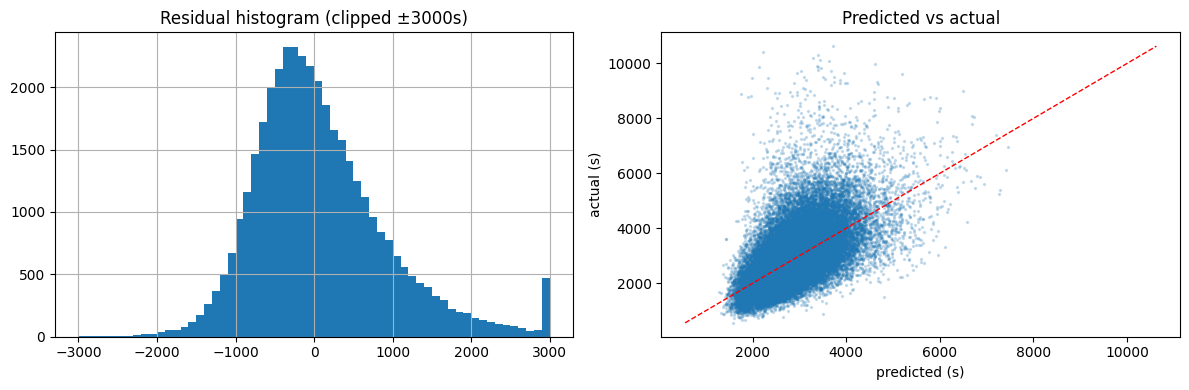

residual mean:   89.5
residual median: -54.6
residual std:    904.1


In [4]:
preds['residual'] = preds['delivery_duration'] - preds[best]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
preds['residual'].clip(-3000, 3000).hist(bins=60, ax=ax[0])
ax[0].set_title('Residual histogram (clipped ±3000s)')
ax[1].scatter(preds[best], preds['delivery_duration'], s=2, alpha=0.2)
lo, hi = preds['delivery_duration'].min(), preds['delivery_duration'].max()
ax[1].plot([lo, hi], [lo, hi], 'r--', linewidth=1)
ax[1].set_xlabel('predicted (s)'); ax[1].set_ylabel('actual (s)')
ax[1].set_title('Predicted vs actual')
plt.tight_layout(); plt.show()

print('residual mean:  ', round(preds['residual'].mean(), 1))
print('residual median:', round(preds['residual'].median(), 1))
print('residual std:   ', round(preds['residual'].std(), 1))

## 2: Worst 100 predictions

In [5]:
preds['abs_error'] = preds['residual'].abs()
worst = preds.sort_values('abs_error', ascending=False).head(100)
print('mean abs_error in top 100:', round(worst['abs_error'].mean(), 1), 's')
worst[['created_at', 'market_id', 'store_primary_category', 'delivery_duration', best, 'abs_error']].head(20)

mean abs_error in top 100:

 5630.7 s


,created_at,market_id,store_primary_category,delivery_duration,pred_XGBoost,abs_error
17630,2015-02-15 05:10:22,5.0,burger,10397.0,2226.1453,8170.8547
13646,2015-02-15 01:37:12,2.0,japanese,9879.0,2143.6084,7735.3916
26699,2015-02-16 04:25:11,2.0,mexican,9483.0,1979.6549,7503.3451
225,2015-02-13 04:27:26,4.0,bubble-tea,9461.0,2317.9805,7143.0195
2682,2015-02-13 21:35:28,4.0,vietnamese,8879.0,1760.5770,7118.4230
33944,2015-02-17 19:38:24,4.0,mediterranean,10201.0,3282.3206,6918.6794
8907,2015-02-14 04:57:35,2.0,dessert,10309.0,3391.0217,6917.9783
34123,2015-02-17 19:56:08,4.0,mediterranean,10626.0,3719.6265,6906.3735
638,2015-02-13 05:27:08,2.0,sushi,8780.0,1892.4153,6887.5847
17584,2015-02-15 05:04:01,6.0,fast,8799.0,1962.1328,6836.8672


### What's distinctive about the worst 100?

In [6]:
preds['hour'] = preds['created_at'].dt.hour
preds['dow']  = preds['created_at'].dt.dayofweek
worst = preds.sort_values('abs_error', ascending=False).head(100)
pd.DataFrame({
    'all_test': preds[['delivery_duration', 'hour']].mean(),
    'worst_100': worst[['delivery_duration', 'hour']].mean(),
}).round(1)

,all_test,worst_100
delivery_duration,2962.7,8635.7
hour,8.3,8.9


## 3: Segment MAE — by hour, day-of-week, market, store category

In [7]:
def segment_mae(df, by):
    g = df.groupby(by, dropna=False, observed=True).apply(
        lambda d: mean_absolute_error(d['delivery_duration'], d[best])
    )
    return g.rename('MAE').to_frame().sort_values('MAE', ascending=False)

for col in ['hour', 'dow', 'market_id', 'store_primary_category']:
    print(f'\n--- worst segments by {col} ---')
    print(segment_mae(preds, col).head(10).round(1))


--- worst segments by hour ---
         MAE
hour        
14    1171.6
15     930.6
16     725.7
3      709.8
2      707.6
17     676.9
19     675.1
1      653.4
5      649.1
4      638.4

--- worst segments by dow ---
       MAE
dow       
0    717.0
6    665.4
5    652.2
1    621.6
2    602.6
4    579.1

--- worst segments by market_id ---
             MAE
market_id       
NaN        805.8
1.0        765.5
3.0        719.8
6.0        641.0
4.0        627.8
5.0        591.0
2.0        590.0

--- worst segments by store_primary_category ---
                           MAE
store_primary_category        
lebanese                1639.2
belgian                 1203.0
spanish                 1051.0
comfort-food            1011.8
moroccan                 906.4
tapas                    882.1
british                  865.6
caribbean                824.3
cheese                   819.9
brazilian                815.5


/var/folders/25/31by454x7wv6kfqx8tzjbryr0000gn/T/ipykernel_55905/3717031746.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g = df.groupby(by, dropna=False, observed=True).apply(
/var/folders/25/31by454x7wv6kfqx8tzjbryr0000gn/T/ipykernel_55905/3717031746.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g = df.groupby(by, dropna=False, observed=True).apply(
/var/folders/25/31by454x7wv6kfqx8tzjbryr0000gn/T/ipyke

## 4: Long-tail performance

In [8]:
def long_tail_breakdown(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    bins = [
        ('<30min',   y_true < 30*60),
        ('30-60min', (y_true >= 30*60) & (y_true <= 60*60)),
        ('>60min',   y_true > 60*60),
    ]
    rows = []
    for label, mask in bins:
        rows.append({
            'bucket': label, 'n': int(mask.sum()),
            'MAE': mean_absolute_error(y_true[mask], y_pred[mask]) if mask.any() else np.nan,
        })
    return pd.DataFrame(rows)

long_tail_breakdown(preds['delivery_duration'], preds[best]).round(1)

,bucket,n,MAE
0,<30min,4399,697.0
1,30-60min,25789,450.3
2,>60min,9269,1192.8
